# Phase 4 — the GCN encoder

Diagnostics for the two-layer graph convolutional encoder in `src/models/`.
Nothing here is trained: **every number and every figure in this notebook
comes from a randomly initialised, untrained encoder.** They are the
baseline the trained encoder (Phase 4b) has to beat, and they would be
badly misread as results if that caveat were dropped, so it is repeated in
every figure title.

What the encoder computes, one rebalance date at a time:

```
A_hat = D^-1/2 (A + I) D^-1/2          normalised adjacency
H     = ReLU(A_hat X W_1)              [105, 13] -> [105, 64]
Z     = A_hat H W_2                    [105, 64] -> [105, 16]
```

Each layer is one hop of neighbourhood averaging followed by a linear map,
so `Z` mixes each asset's own features with those of its correlation
neighbours out to two hops. Across the whole stack:

| artefact | shape | role |
|---|---|---|
| `features.npz / X` | `[128, 105, 13]` | node features per rebalance date |
| `graphs.npz / A` | `[128, 105, 105]` | correlation kNN adjacency per date |
| `Z = enc(X, A)` | `[128, 105, 16]` | embeddings — the object Phase 5 clusters |

The checks, in order: the normalised adjacency's spectrum (1), layer shapes
and permutation equivariance (2), how variance propagates through random
weights (3), how many directions of `Z` actually carry information (4), and
whether the propagation operator alone already separates sectors (5).

In [1]:
from pathlib import Path
import os

ROOT = Path.cwd()
while not (ROOT / ".git").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
print("anchored at:", ROOT)

anchored at: /Users/tony/Library/Mobile Documents/com~apple~CloudDocs/equity-graph-clustering


## Setup

Imports, the seed, the two artefacts and the sector labels.

The encoder weights are random, so **the seed is what makes every baseline
number below reproducible** — change it and the numbers change, and a
comparison against a later trained run is only meaningful if both come from
the same draw. `torch.manual_seed` is set immediately before the encoder is
constructed, which is the moment the weights are drawn; the seed is
`training.seed` from `config/base.yaml` so the trained run will share it.

The encoder is put in `eval()` mode and every forward pass runs under
`torch.no_grad()`. This disables dropout; with it on, the same input would
give a different `Z` on every call and nothing here would reproduce from
one cell to the next.

Sector labels come from `load_sector_labels`, which normalises the
`BRK.B` / `BRK-B` mismatch between the universe CSV and the artefacts and
fails loudly if any ticker is left without a sector.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch, yaml
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from src.models.layers import normalise_adjacency
from src.models.encoder import GCNEncoder
from src.graphs.homophily import load_sector_labels

cfg = yaml.safe_load(open('config/base.yaml'))
SEED = cfg['training']['seed']
torch.manual_seed(SEED); np.random.seed(SEED)

f = np.load('data/processed/features.npz', allow_pickle=True)
g = np.load('data/processed/graphs.npz', allow_pickle=True)
X_np, A_np = f['X'], g['A']
tickers = [str(t) for t in f['tickers']]
dates   = pd.to_datetime(f['dates'])
fnames  = [str(s) for s in f['feature_names']]

# Node and date order must agree across the two artefacts, or every check
# below silently pairs one asset's features with another's neighbourhood.
assert tickers == [str(t) for t in g['tickers']]
assert list(f['dates']) == list(g['dates'])

labels  = load_sector_labels('data/universe_sp100.csv', tickers)
sectors = sorted(set(labels))

X = torch.tensor(X_np, dtype=torch.float32)      # [T, N, F]
A = torch.tensor(A_np, dtype=torch.float32)      # [T, N, N]
T, N, F = X.shape

# The seed above governs this draw. Defaults match config/base.yaml:model.
enc = GCNEncoder(in_dim=F).eval()
m = cfg['model']
assert [tuple(l.weight.shape) for l in enc.layers] == \
       [(F, m['hidden_dim']), (m['hidden_dim'], m['embed_dim'])]
assert enc.dropout.p == m['dropout'] and not enc.training

t_mid    = 60                                                # as in 03_graphs
t_crisis = dates.get_indexer([pd.Timestamp('2020-03-31')], method='nearest')[0]
t_calm   = dates.get_indexer([pd.Timestamp('2019-06-30')], method='nearest')[0]

C_X, C_Z = '#2a78d6', '#eb6834'                  # X is blue, Z is orange, throughout

print(f"X {tuple(X.shape)}  A {tuple(A.shape)}  {len(sectors)} sectors  seed {SEED}")
print("mid-sample:", dates[t_mid].date(), "| crisis:", dates[t_crisis].date(),
      "| calm:", dates[t_calm].date())
print("encoder:", [tuple(l.weight.shape) for l in enc.layers],
      f"dropout {enc.dropout.p} (inactive: eval mode)")

X (128, 105, 13)  A (128, 105, 105)  11 sectors  seed 42
mid-sample: 2021-01-29 | crisis: 2020-03-31 | calm: 2019-06-28
encoder: [(13, 64), (64, 16)] dropout 0.2 (inactive: eval mode)


## Check 1 — the normalised adjacency

`normalise_adjacency` builds `A_hat = D^-1/2 (A + I) D^-1/2`, where `D` is
the degree matrix of `A + I`. Three things should hold, and the cell asserts
each of them at the mid-sample date:

1. **Symmetry** — `A` is symmetric and the normalisation is two-sided, so
   `A_hat` must be too. That is what makes its eigenvalues real and its
   eigenvectors orthogonal.
2. **Largest eigenvalue exactly 1.** For non-negative weights `A_hat` is
   similar to the random-walk matrix `D^-1 (A + I)`, whose spectral radius
   is 1, and the eigenvalue 1 is simple when the graph is connected.
3. **The eigenvector at 1 is `D^1/2 1`.** Directly:
   `A_hat D^1/2 1 = D^-1/2 (A + I) 1 = D^-1/2 D 1 = D^1/2 1`.

That top eigenvector is the **DC mode**: a constant vector, reweighted by
`sqrt(degree)`. It matters because stacking layers applies `A_hat`
repeatedly, and `A_hat^L = sum_k lambda_k^L u_k u_k^T`. With every
`|lambda_k| < 1` except the first, every component except DC decays as
`lambda_k^L` and the DC mode is the only one that survives. That is
oversmoothing stated in eigenvalues: a deep enough stack maps every node's
features onto the same vector, and clustering the result is impossible.
The second eigenvalue sets the rate — the closer `lambda_2` is to 1, the
slower the decay and the more depth the graph tolerates.

In [3]:
A_hat = normalise_adjacency(A)                       # [T, N, N], batched
A_t = A_hat[t_mid]

assert torch.allclose(A_t, A_t.T, atol=1e-6), "A_hat is not symmetric"

w = torch.linalg.eigvalsh(A_t)                       # ascending
assert abs(w[-1].item() - 1.0) < 1e-5, f"max eigenvalue {w[-1].item()}"

deg = (A[t_mid] + torch.eye(N)).sum(1)
v = deg.sqrt()                                       # D^1/2 1
assert torch.allclose(A_t @ v, v, atol=1e-5), "D^1/2 1 is not the eigenvector at 1"

print(f"{dates[t_mid].date()}   max asymmetry {(A_t - A_t.T).abs().max():.1e}")
print(f"eigenvalues: max {w[-1]:.6f}   second {w[-2]:.4f}   min {w[0]:.4f}")
print(f"|A_hat v - v| max {(A_t @ v - v).abs().max():.1e}   (v = D^1/2 1)")
print(f"second mode retained per layer: lambda_2 = {w[-2]:.4f};   "
      f"after 2 layers {w[-2]**2:.3f}, after 10 {w[-2]**10:.3f}, after 50 {w[-2]**50:.3f}")

2021-01-29   max asymmetry 1.5e-08
eigenvalues: max 0.999999   second 0.9497   min -0.0588
|A_hat v - v| max 4.8e-07   (v = D^1/2 1)
second mode retained per layer: lambda_2 = 0.9497;   after 2 layers 0.902, after 10 0.597, after 50 0.076


`lambda_2 = 0.95` is close to 1, so a two-layer stack keeps 90% of the
amplitude of the slowest non-DC mode and oversmoothing is not a concern at
this depth; it would be at fifty layers, where the same mode is down to 8%.

The same three checks now run over all 128 dates. The eigenvector identity
and the existence of an eigenvalue at 1 are algebraic and cannot fail, but
"1 is the *largest* eigenvalue" depends on the weights being non-negative,
and the sweep is where that assumption gets tested rather than assumed.

In [4]:
w_all   = torch.linalg.eigvalsh(A_hat)               # [T, N]
deg_all = (A + torch.eye(N)).sum(-1)
v_all   = deg_all.sqrt()
resid   = ((A_hat @ v_all.unsqueeze(-1)).squeeze(-1) - v_all).abs().amax(1)
mult    = ((w_all - 1).abs() < 1e-4).sum(1)          # multiplicity of eigenvalue 1

assert (resid < 1e-5).all(), "eigenvector identity fails on some date"
assert (mult == 1).all(), "eigenvalue 1 is not simple: a graph is disconnected"

rowsum = A_np.sum(2)                                 # row sums of A, without I
spec = pd.DataFrame({
    'lam_max':   w_all[:, -1].numpy(),
    'lam_2':     w_all[:, -2].numpy(),
    'lam_min':   w_all[:, 0].numpy(),
    'neg_edges': (A_np < 0).sum((1, 2)) // 2,
    'min_row_sum': rowsum.min(1),
    'min_row_node': [tickers[i] for i in rowsum.argmin(1)],
}, index=dates)
over = spec[spec['lam_max'] > 1 + 1e-5]

print(f"all {T} graphs connected; eigenvector identity holds to {resid.max():.1e}")
print(f"largest eigenvalue: {(spec['lam_max'] - 1).abs().lt(1e-5).sum()} of {T} dates at 1.0")
print(f"lambda_2: mean {spec['lam_2'].mean():.4f}, "
      f"range [{spec['lam_2'].min():.4f}, {spec['lam_2'].max():.4f}]")
print(f"dates with negative edge weights: {(spec['neg_edges'] > 0).sum()}   "
      f"({int(spec['neg_edges'].sum())} edges of {int((A_np != 0).sum() // 2)})")
print(f"\ndates where lambda_max > 1: {len(over)}")
print(over.round(4).to_string())

all 128 graphs connected; eigenvector identity holds to 9.5e-07
largest eigenvalue: 125 of 128 dates at 1.0
lambda_2: mean 0.9430, range [0.8709, 1.0000]
dates with negative edge weights: 12   (53 edges of 91370)

dates where lambda_max > 1: 3
            lam_max  lam_2  lam_min  neg_edges  min_row_sum min_row_node
2017-11-30   1.1217    1.0   0.0300          6      -0.0751          AMD
2017-12-29   1.1548    1.0   0.0223          8      -0.1041          AMD
2018-01-31   1.0641    1.0   0.0231          7      -0.0230          AMD


### A construction artefact the sweep exposes

On **three dates — 2017-11-30, 2017-12-29 and 2018-01-31 — the largest
eigenvalue exceeds 1** (1.12, 1.15, 1.06). Eigenvalue 1 with eigenvector
`D^1/2 1` is still there on those dates; it has just stopped being the top
of the spectrum, and the assertion in the previous cell would fail on them.

The cause is negative edge weights. Phase 3 builds a signed kNN: each asset
keeps its ten highest residual correlations, weighted by the correlation
itself, and nothing stops the tenth-highest from being negative. Twelve
dates carry at least one negative weight. On nine of them (2021) the
negatives are of order 1e-5 and change nothing. On the three above, AMD's
ten neighbours include six to eight negative residual correlations, its row
sum of `A` is negative, and its degree in `A + I` drops below 1. The bound
`|lambda| <= 1` rests on Perron–Frobenius, which needs non-negative
weights, and with that gone the spectral radius is free to exceed 1.
Clipping the negatives at zero restores `lambda_max = 1` on all three.

This is not a bug in `normalise_adjacency`; it is a property of the graph
handed to it, reported rather than patched because the fix (clip at zero,
or admit only positive correlations) belongs in graph construction and
changes a Phase 3 artefact. What it means for the encoder: on those three
dates one non-DC component is amplified by each layer instead of damped, so
the oversmoothing argument above runs in the wrong direction there.
Training will be walk-forward, so the exposure is confined to windows that
include late 2017.

## Check 2 — layer sanity

Two things. First, the shape map: `[105, 13]` in, `[105, 64]` after the
first layer, `[105, 16]` out — and, because both `normalise_adjacency` and
`GraphConv` broadcast over a leading batch axis, the whole stack goes
through in one call as `[128, 105, 13] -> [128, 105, 16]`. The cell also
rebuilds `Z` layer by layer and checks it matches `enc(X, A)`, so the
intermediate `H` used in Check 3 is the one the encoder actually computes.

Second, **permutation equivariance**: relabelling the nodes must relabel
the embeddings and change nothing else, `f(PX, PAP^T) = P f(X, A)`. This is
the property that makes a GCN a model of the graph rather than of node
index order — nothing in the output may depend on which row an asset
happens to occupy. `tests/test_layers.py` checks it for one layer on a
random adjacency; this cell checks the full two-layer encoder on a real
graph with an explicit permutation matrix.

In [5]:
with torch.no_grad():
    H_pre = enc.layers[0](X, A_hat)                  # [T, N, 64], pre-activation
    H     = torch.relu(H_pre)
    Z     = enc.layers[1](H, A_hat)                  # [T, N, 16]
    assert torch.allclose(Z, enc(X, A), atol=1e-6)

print(f"X {tuple(X.shape)} -> H {tuple(H.shape)} -> Z {tuple(Z.shape)}")

perm = torch.randperm(N)
P = torch.eye(N)[perm]                               # permutation matrix
Xt, At = X[t_mid], A[t_mid]
with torch.no_grad():
    lhs = enc(P @ Xt, P @ At @ P.T)                  # f(PX, PAP^T)
    rhs = P @ enc(Xt, At)                            # P f(X, A)
gap = (lhs - rhs).abs().max().item()
assert gap < 1e-5, f"equivariance broken: {gap}"
print(f"f(PX, PAP^T) vs P f(X, A): max |diff| {gap:.1e}   "
      f"(entries are of order {rhs.abs().max():.2f})")

X (128, 105, 13) -> H (128, 105, 64) -> Z (128, 105, 16)
f(PX, PAP^T) vs P f(X, A): max |diff| 4.8e-07   (entries are of order 1.17)


## Check 3 — variance propagation

How the scale of the signal changes as it passes through random weights.
`GraphConv` uses Glorot initialisation, `Var(W) = 2 / (n_in + n_out)`,
chosen to keep the forward *and* backward signal at roughly constant scale.
The alternative, Kaiming, uses `Var(W) = 2 / n_in` and preserves forward
variance through a ReLU exactly, at the expense of the backward pass.

The ratio of the two is `(n_in + n_out) / n_in` per layer, so across this
encoder the output variance under Kaiming should be larger by

```
(13 + 64) / 13  x  (64 + 16) / 64  =  5.92 x 1.25  =  7.4
```

Variances are taken over the whole `[128, 105, .]` stack. Two encoders are
compared: the seeded Glorot one from Setup, and a copy re-initialised with
Kaiming from an independent draw. Kaiming is applied by hand because
`GraphConv` stores its weight as `[in, out]`, and `torch.nn.init.kaiming_*`
would read the fan-in off the wrong axis.

In [6]:
import copy, math

def variance_chain(e):
    with torch.no_grad():
        h_pre = e.layers[0](X, A_hat); h = torch.relu(h_pre); z = e.layers[1](h, A_hat)
    return {'input': X.var().item(), 'hidden, pre-ReLU': h_pre.var().item(),
            'hidden, post-ReLU': h.var().item(), 'output': z.var().item()}, z

def erank(M):
    """exp of the spectral entropy of M's singular values (defined in Check 4)."""
    s = torch.linalg.svdvals(M); p = s / s.sum(); p = p[p > 0]
    return torch.exp(-(p * p.log()).sum()).item()

def kaiming_copy(e, seed):
    k = copy.deepcopy(e); torch.manual_seed(seed)
    for layer in k.layers:
        fan_in = layer.weight.shape[0]                # weight is [in, out]
        bound = math.sqrt(6.0 / fan_in)               # uniform with Var = 2 / fan_in
        torch.nn.init.uniform_(layer.weight, -bound, bound)
    return k.eval()

rng_state = torch.get_rng_state()                    # the re-seeding below must not
                                                     # leak into anything downstream
var_g, Z_g = variance_chain(enc)
var_k, Z_k = variance_chain(kaiming_copy(enc, SEED + 1))

tab = pd.DataFrame({'Glorot': var_g, 'Kaiming': var_k})
tab.loc['effective rank of Z, mean over dates'] = [
    np.mean([erank(Z_g[t]) for t in range(T)]),
    np.mean([erank(Z_k[t]) for t in range(T)])]
tab['ratio K/G'] = tab['Kaiming'] / tab['Glorot']
print(tab.round(4).to_string())
print(f"\npredicted output-variance ratio: {(F + 64) / F * (64 + 16) / 64:.2f}")

# One draw is noisy with a 13 x 64 matrix; average the ratio over re-draws.
ratios = []
for s in range(100, 120):
    torch.manual_seed(s); e_g = GCNEncoder(in_dim=F).eval()
    ratios.append(variance_chain(kaiming_copy(e_g, s + 1000))[0]['output']
                  / variance_chain(e_g)[0]['output'])
print(f"ratio over 20 independent Glorot/Kaiming pairs: mean {np.mean(ratios):.2f}, "
      f"std {np.std(ratios):.2f}, range [{min(ratios):.2f}, {max(ratios):.2f}]")
torch.set_rng_state(rng_state)

                                      Glorot  Kaiming  ratio K/G
input                                 1.3745   1.3745     1.0000
hidden, pre-ReLU                      0.1673   1.0195     6.0928
hidden, post-ReLU                     0.0514   0.4106     7.9914
output                                0.0705   1.0419    14.7696
effective rank of Z, mean over dates  8.4168   7.5999     0.9029

predicted output-variance ratio: 7.40


ratio over 20 independent Glorot/Kaiming pairs: mean 7.43, std 2.52, range [2.98, 14.01]


### Reading the table

This draw gives an output-variance ratio of **14.8×**; averaged over twenty
independent re-draws it is **7.4×**, which is the predicted
`(n_in + n_out) / n_in` compounded across the two layers. A single ratio is
noisy because a 13 × 64 weight matrix has few enough entries for its
realised variance to sit a long way from its expectation — the twenty-draw
range runs from 3× to 14×, and the interactive session that preceded this
notebook recorded "roughly 10×" from one such draw. The same scatter is
visible inside the table: the hidden-layer ratio should be 5.9 from the
first factor alone and comes out at 8.0 here, because the two encoders'
first-layer weights are independent draws, not one draw rescaled.

**Glorot is kept.** Scale is not the quantity that matters: the next
layer's weights absorb any constant factor during training, and the
objective is invariant to it. What matters is how many directions of `Z`
carry information, and the effective rank moves far less than the variance
does — 8.4 under Glorot against 7.6 under Kaiming, a tenth, for a
fifteen-fold change in scale. Kaiming buys a louder signal and no extra
structure.

## Check 4 — spectral entropy and effective rank

How many directions of the embedding space actually carry information, and
how that compares with the raw features. For the singular values
`s_1 >= ... >= s_d` of a matrix `Z`, normalise them into a distribution,

```
p_k = s_k / sum_j s_j
```

and define the **spectral entropy** `H = -sum_k p_k log p_k` and the
**effective rank** `erank(Z) = exp(H)`. This is a continuous count of the
dimensions genuinely in use: a perfectly flat spectrum over `d` dimensions
gives `erank = d`, a rank-one matrix gives `erank = 1`, and everything real
sits between.

Ceilings. `X[t]` has 13 columns, so `erank(X) <= 13`, and the first layer's
pre-activation `A_hat X W_1` inherits that rank exactly — a linear map
cannot create directions. The ReLU can: it is applied elementwise and is
not linear, so `H = ReLU(A_hat X W_1)` has rank up to 64 and `Z` up to
`embed_dim = 16`. The cell checks the algebraic ranks to confirm that this
is what happens. The `n_features = 13` line in Figure 4b is therefore the
ceiling for `X`, and for what a *linear* encoder could pass on; the ceiling
for this encoder's `Z` is 16.

An effective rank near either ceiling would mean a flat spectrum — every
direction equally loud, which is what uncorrelated noise looks like. A
value near 1 would mean collapse onto one direction, which is what
oversmoothing looks like. A trained encoder should sit well inside both,
and where it sits relative to this baseline is the first thing to
re-measure.

algebraic rank at 2021-01-29: X 13 | A_hat X W1 13 | ReLU(A_hat X W1) 64 | Z 16


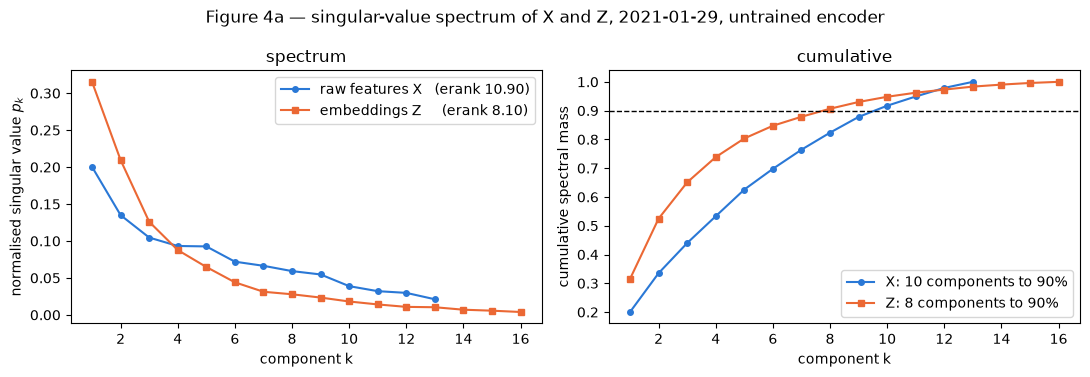

In [7]:
def spectrum(M):
    s = torch.linalg.svdvals(M); return (s / s.sum()).numpy()

n90 = lambda p: int((np.cumsum(p) < 0.9).sum() + 1)   # components to 90% of mass

print(f"algebraic rank at {dates[t_mid].date()}:",
      f"X {torch.linalg.matrix_rank(X[t_mid]).item()}",
      f"| A_hat X W1 {torch.linalg.matrix_rank(H_pre[t_mid]).item()}",
      f"| ReLU(A_hat X W1) {torch.linalg.matrix_rank(H[t_mid]).item()}",
      f"| Z {torch.linalg.matrix_rank(Z[t_mid]).item()}")

pX, pZ = spectrum(X[t_mid]), spectrum(Z[t_mid])
kX, kZ = np.arange(1, len(pX) + 1), np.arange(1, len(pZ) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(kX, pX, 'o-', ms=4, color=C_X, label=f'raw features X   (erank {erank(X[t_mid]):.2f})')
ax[0].plot(kZ, pZ, 's-', ms=4, color=C_Z, label=f'embeddings Z     (erank {erank(Z[t_mid]):.2f})')
ax[0].set_xlabel('component k'); ax[0].set_ylabel('normalised singular value $p_k$')
ax[0].set_title('spectrum'); ax[0].legend()
ax[1].plot(kX, np.cumsum(pX), 'o-', ms=4, color=C_X, label=f'X: {n90(pX)} components to 90%')
ax[1].plot(kZ, np.cumsum(pZ), 's-', ms=4, color=C_Z, label=f'Z: {n90(pZ)} components to 90%')
ax[1].axhline(0.9, color='k', ls='--', lw=1)
ax[1].set_xlabel('component k'); ax[1].set_ylabel('cumulative spectral mass')
ax[1].set_title('cumulative'); ax[1].legend(loc='lower right')
fig.suptitle(f'Figure 4a — singular-value spectrum of X and Z, '
             f'{dates[t_mid].date()}, untrained encoder')
plt.tight_layout(); plt.show()

Figure 4a is one date. Figure 4b runs the same statistic over all 128
dates, to see whether the encoder's spectral behaviour is stable over time
or moves with the regime, and Figure 4c is the distribution of that
statistic for `Z` — the spread of the effective rank, rather than a single
snapshot. A trained encoder should be compared against the whole
distribution, not the one date in 4a.

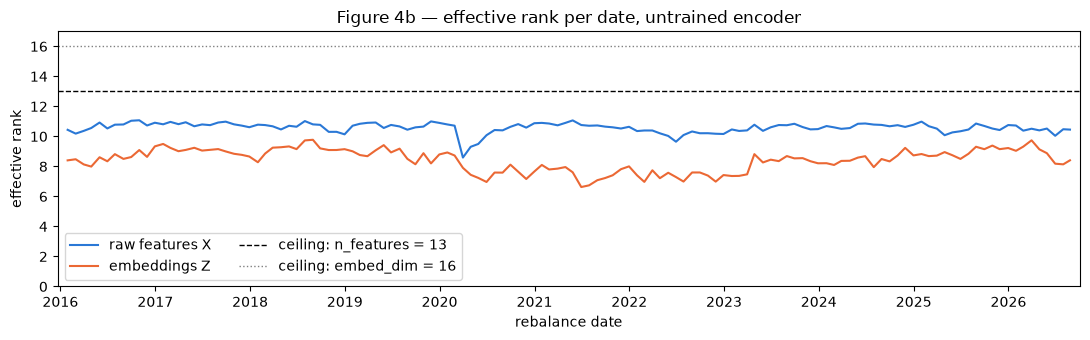

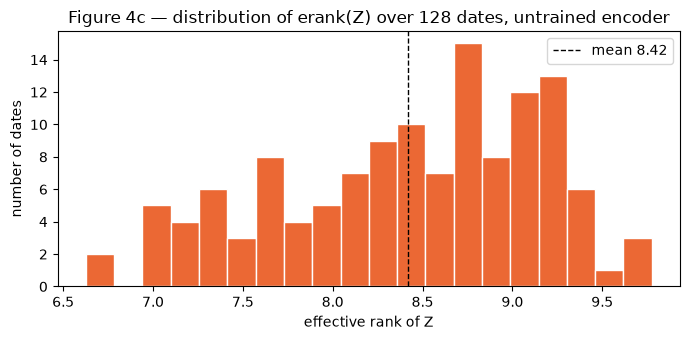

     mean    std    min     max
X  10.577  0.347  8.590  11.074
Z   8.417  0.734  6.627   9.775

erank(Z) is lowest on 2021-06-30 (6.627) and highest on 2018-08-31 (9.775)
correlation between the two series: 0.39


In [8]:
er = pd.DataFrame({'X': [erank(X[t]) for t in range(T)],
                   'Z': [erank(Z[t]) for t in range(T)]}, index=dates)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(er.index, er['X'], color=C_X, lw=1.5, label='raw features X')
ax.plot(er.index, er['Z'], color=C_Z, lw=1.5, label='embeddings Z')
ax.axhline(13, color='k', ls='--', lw=1, label='ceiling: n_features = 13')
ax.axhline(16, color='0.5', ls=':', lw=1, label='ceiling: embed_dim = 16')
ax.set_ylim(0, 17); ax.margins(x=0.01)
ax.set_xlabel('rebalance date'); ax.set_ylabel('effective rank')
ax.legend(loc='lower left', ncol=2)
ax.set_title('Figure 4b — effective rank per date, untrained encoder')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(er['Z'], bins=20, color=C_Z, edgecolor='white')
ax.axvline(er['Z'].mean(), color='k', ls='--', lw=1, label=f"mean {er['Z'].mean():.2f}")
ax.set_xlabel('effective rank of Z'); ax.set_ylabel('number of dates'); ax.legend()
ax.set_title(f'Figure 4c — distribution of erank(Z) over {T} dates, untrained encoder')
plt.tight_layout(); plt.show()

print(er.agg(['mean', 'std', 'min', 'max']).T.round(3).to_string())
print(f"\nerank(Z) is lowest on {er['Z'].idxmin().date()} ({er['Z'].min():.3f}) "
      f"and highest on {er['Z'].idxmax().date()} ({er['Z'].max():.3f})")
print(f"correlation between the two series: {er['X'].corr(er['Z']):.2f}")

### Reading the spectra

`erank(X)` averages **10.6 of a possible 13** (std 0.35): the raw features
are close to spectrally flat, which is what a set of standardised risk
measures should look like once Phase 2 has removed the two near-duplicates.
`erank(Z)` averages **8.4 of a possible 16** (std 0.73, range 6.6 to 9.8):
the random encoder concentrates the spectrum rather than flattening it. At
the mid-sample date the leading component holds 32% of `Z`'s spectral mass
against 20% of `X`'s, and 90% of the mass takes 8 components for `Z`
against 10 for `X`. That concentration is mostly `A_hat`: two hops of
averaging are a low-pass filter, and a low-pass filter loads mass onto a few
leading directions, Check 1's DC mode first among them.

Well above 1 and well below both ceilings, then — the untrained encoder
neither collapses nor whitens. But the series is not flat in time, and the
two inputs respond to the 2020 regime differently. `erank(X)` has one sharp
trough, **8.59 on 2020-03-31**, the crash date itself: with the whole
cross-section moving on one axis (Figure 5b's PC1 carries 63% of the
variance there) the thirteen features become briefly co-linear, and the
statistic is back to 9.3 the following month. `erank(Z)` instead steps down
and stays down: 8.9 on average over 2016–19, **7.5 over 2020–22**, back to
8.6 from 2023. `X` moves by 0.3 over the same stretch and `Z` by 1.4, so
the change comes through `A_hat`, not the features — and it means the
encoder's spectral behaviour does vary with regime, by about one and a
half effective dimensions. Figure 4c is correspondingly two-lumped, the
2020–22 trough and everything else, with no tail toward 1; oversmoothing
would show up as that tail. The low of the series is 2021-06-30, the high
2018-08-31, and its correlation with `erank(X)` is only 0.39 — the same
point again: what moves `erank(Z)` is mostly not what moves `erank(X)`.

## Check 5 — the untrained baseline embedding space

Does the graph convolution alone — before any training — already improve
sector separation relative to the raw features? Whatever the answer, it is
the baseline the trained encoder must beat, and measuring it separates two
things that would otherwise be confounded: structure that comes from the
propagation operator `A_hat`, and structure that comes from learning.

The projection is PCA, fitted separately for `X[t]` and `Z[t]` because they
live in different spaces. PCA rather than UMAP or t-SNE because it is
deterministic, adds no dependency, and its axes mean something — the
directions of largest variance, with the fraction each explains written on
the axis label. Sector identity is carried by colour *and* marker shape:
eleven categories is more than colour alone can keep apart, for any
palette, so the marker is the second channel.

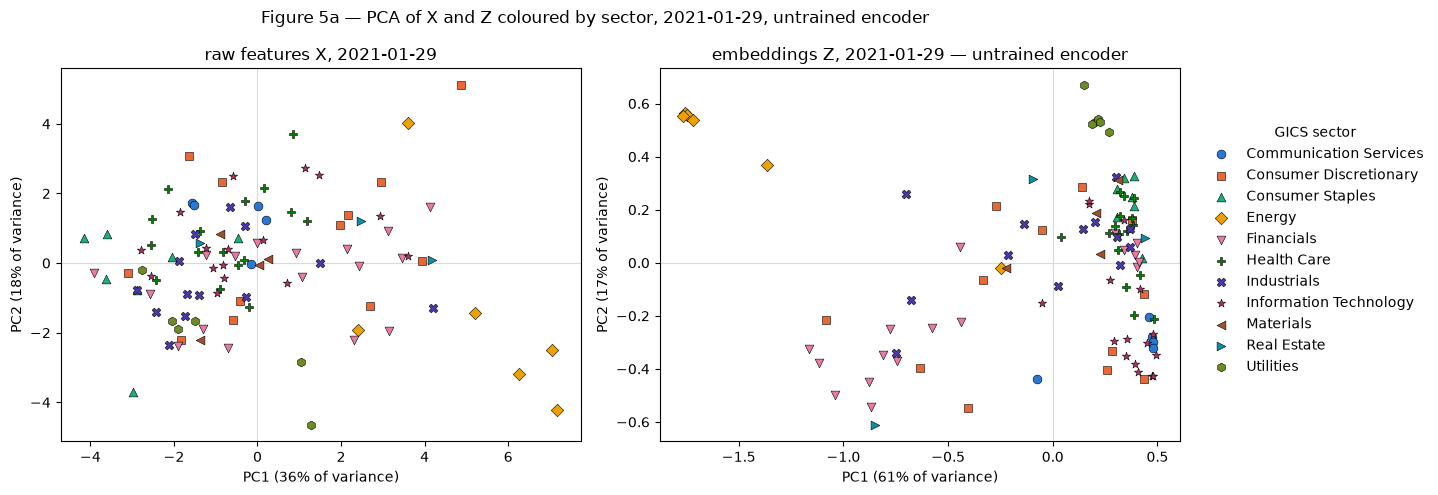

In [9]:
# One fixed sector -> (colour, marker) map, used by every panel below, so a
# sector keeps its identity across figures. Eleven categories cannot all be
# colour-separable, hence the marker as a second channel.
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300',
           '#4a3aa7', '#b03060', '#a0522d', '#0e8fa6', '#6b8e23']
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h']
assert len(sectors) <= len(PALETTE)
style = {s: (PALETTE[i], MARKERS[i]) for i, s in enumerate(sectors)}

def pca_panel(ax, M, title):
    p = PCA(n_components=2).fit(M); Y = p.transform(M)
    for s in sectors:
        keep = labels == s
        ax.scatter(Y[keep, 0], Y[keep, 1], s=40, color=style[s][0], marker=style[s][1],
                   edgecolors='black', linewidths=0.4, label=s)
    ev = p.explained_variance_ratio_
    ax.axhline(0, color='0.85', lw=0.8, zorder=0); ax.axvline(0, color='0.85', lw=0.8, zorder=0)
    ax.set_xlabel(f'PC1 ({ev[0]:.0%} of variance)'); ax.set_ylabel(f'PC2 ({ev[1]:.0%} of variance)')
    ax.set_title(title)

def pca_pair(t, axes):
    pca_panel(axes[0], X_np[t], f'raw features X, {dates[t].date()}')
    pca_panel(axes[1], Z[t].numpy(), f'embeddings Z, {dates[t].date()} — untrained encoder')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pca_pair(t_mid, axes)
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, loc='center left', bbox_to_anchor=(1.0, 0.5),
           title='GICS sector', frameon=False)
fig.suptitle(f'Figure 5a — PCA of X and Z coloured by sector, '
             f'{dates[t_mid].date()}, untrained encoder')
plt.tight_layout(); plt.show()

Figure 5b repeats the pair for a crisis date and a calm one — the rebalance
dates nearest 2020-03-31 and 2019-06-30 — to see whether whatever
separation exists is regime dependent. The COVID date is the one on which
Phase 3 found edge persistence at its 0.33 low and homophily at its trough:
the graph itself is least sector-like there, so if `Z` inherits its
structure from `A_hat`, that is where the sector picture should be weakest.

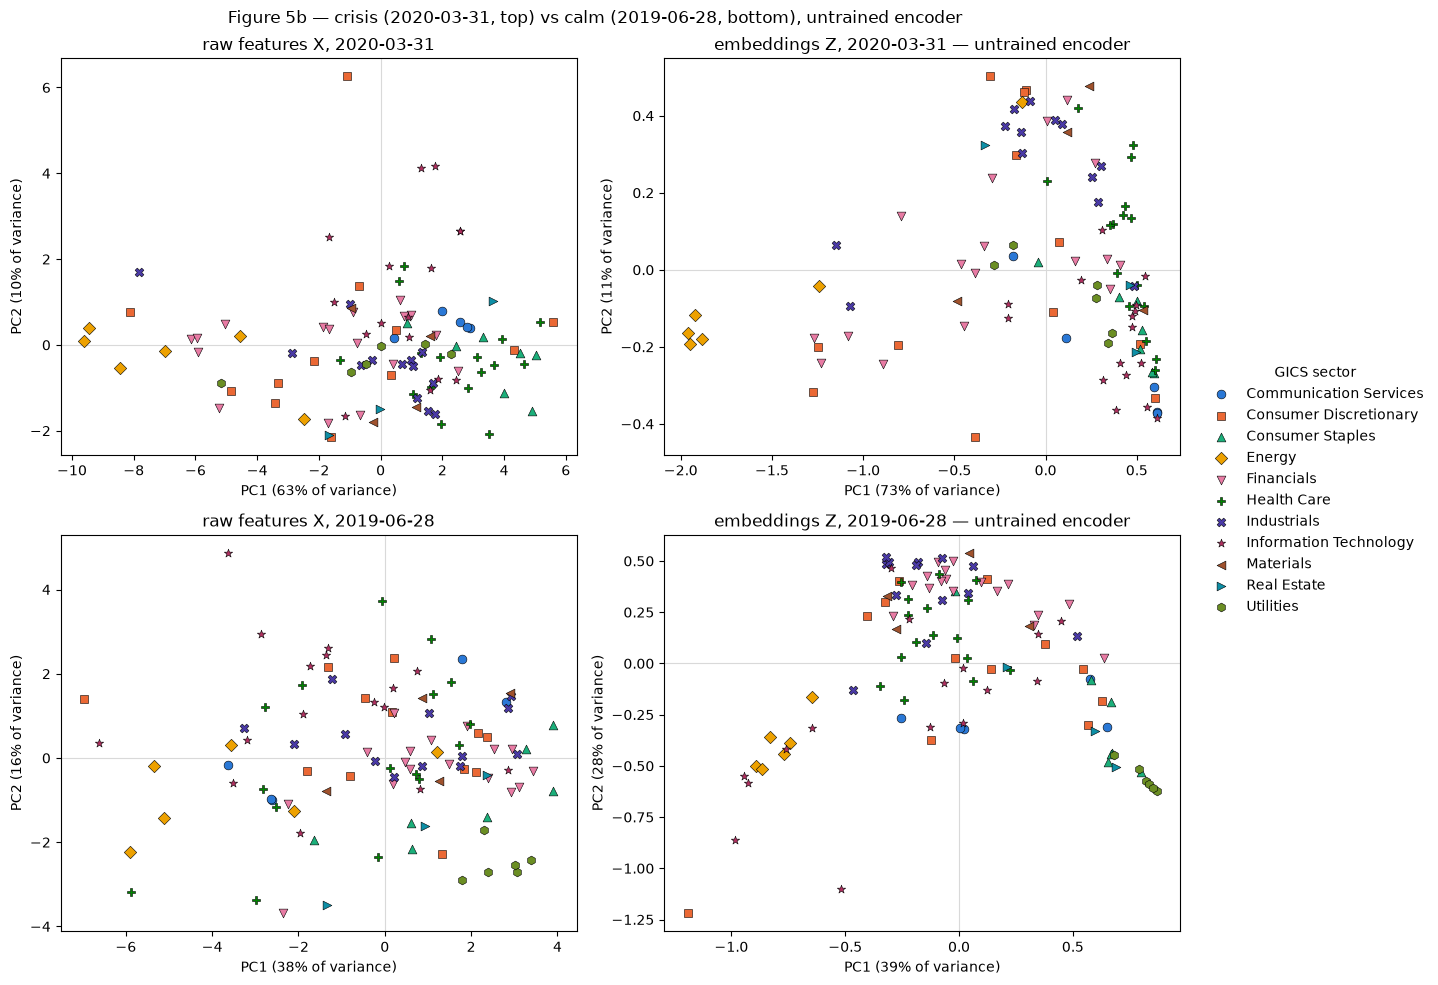

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
pca_pair(t_crisis, axes[0]); pca_pair(t_calm, axes[1])
handles, names = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, names, loc='center left', bbox_to_anchor=(1.0, 0.5),
           title='GICS sector', frameon=False)
fig.suptitle(f'Figure 5b — crisis ({dates[t_crisis].date()}, top) vs calm '
             f'({dates[t_calm].date()}, bottom), untrained encoder')
plt.tight_layout(); plt.show()

### Silhouette against sector labels

The pictures are two-dimensional projections; the number that goes with
them is computed in the full space. The **silhouette score** takes each
asset, compares its mean distance to the other members of its own sector
(`a`) with its mean distance to the members of the nearest other sector
(`b`), and reports `(b - a) / max(a, b)` averaged over assets. It lies in
`[-1, 1]`: positive means assets sit closer to their own sector than to any
other, zero means sectors are not distinguishable as clusters, negative
means the typical asset is closer to some other sector than to its own.

What it measures: how much *GICS sectors* look like clusters in the given
space, under Euclidean distance. What it does not measure: cluster quality
in any other sense, whether some other grouping exists, or anything about
a training objective — nothing here has been trained.

Two things to expect. **A negative or near-zero score is the normal result
and does not indicate a bug.** Sectors are not clean clusters in a
13-dimensional standardised risk-feature space; a utility and a bank can
share a volatility, beta and liquidity profile. And if `Z` scores higher
than `X`, that is a property of the propagation operator `A_hat`, not of
anything learned: averaging each asset with its correlation neighbours
pulls it toward assets that Phase 3 showed are disproportionately in its
own sector. The trained encoder has to beat the `Z` number, not the `X`
one.

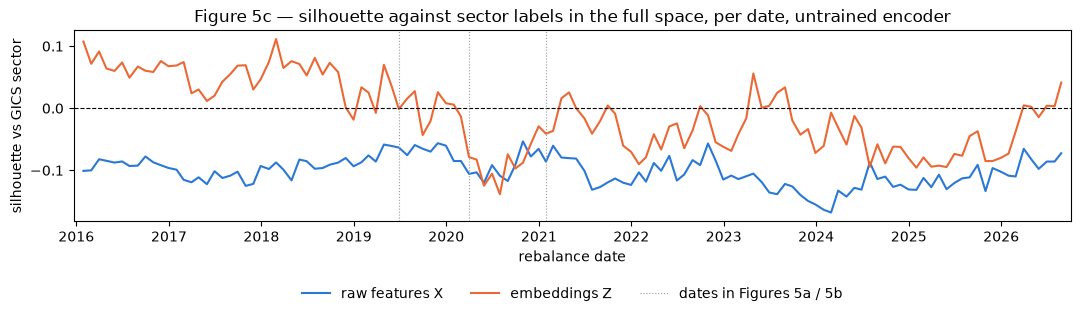

     mean     std     min     max
X -0.1014  0.0235 -0.1680 -0.0534
Z -0.0099  0.0583 -0.1385  0.1115

Z scores above X on 95% of dates
 mid-sample 2021-01-29:  X -0.0860   Z -0.0411
     crisis 2020-03-31:  X -0.1058   Z -0.0787
       calm 2019-06-28:  X -0.0634   Z -0.0014


In [11]:
sil = pd.DataFrame({'X': [silhouette_score(X_np[t], labels) for t in range(T)],
                    'Z': [silhouette_score(Z[t].numpy(), labels) for t in range(T)]},
                   index=dates)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(sil.index, sil['X'], color=C_X, lw=1.5, label='raw features X')
ax.plot(sil.index, sil['Z'], color=C_Z, lw=1.5, label='embeddings Z')
ax.axhline(0, color='k', lw=0.8, ls='--')
for t in (t_calm, t_crisis, t_mid):
    ax.axvline(dates[t], color='0.6', lw=0.8, ls=':')
ax.plot([], [], color='0.6', lw=0.8, ls=':', label='dates in Figures 5a / 5b')
ax.margins(x=0.01)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.28), ncol=3, frameon=False)
ax.set_xlabel('rebalance date'); ax.set_ylabel('silhouette vs GICS sector')
ax.set_title('Figure 5c — silhouette against sector labels in the full space, '
             'per date, untrained encoder')
plt.tight_layout(); plt.show()

print(sil.agg(['mean', 'std', 'min', 'max']).T.round(4).to_string())
print(f"\nZ scores above X on {(sil['Z'] > sil['X']).mean():.0%} of dates")
for t, nm in [(t_mid, 'mid-sample'), (t_crisis, 'crisis'), (t_calm, 'calm')]:
    print(f"{nm:>11} {dates[t].date()}:  X {sil['X'].iloc[t]:+.4f}   Z {sil['Z'].iloc[t]:+.4f}")

### Reading the silhouettes

`X` is negative on every date (max −0.053): in the raw feature space,
sectors are not clusters, as expected. `Z` is a different picture. It sits
above `X` on 95% of dates, mean **−0.010 against −0.101**, and for the
first four years it is mostly *positive* — 0.047 on average over 2016–19,
peaking at 0.11 in early 2018 — before dropping through 2020 to a low of
−0.14 in July 2020 and settling near −0.045 from then on. Two hops of
neighbourhood averaging with random weights move the assets toward their
own sectors, by a tenth of a silhouette unit on average and by more than
that before 2020. That is the propagation operator at work: Phase 3
measured the correlation graph's adjusted homophily at 0.30, so each
asset's neighbourhood is disproportionately its own sector, and averaging
over it pulls same-sector assets together.

The gain is regime dependent, in the direction Phase 3 predicts. The
`Z − X` gap averages 0.14 over 2016–19, 0.05 over 2020–22 and 0.08 after.
On the calm date it is 0.06 (−0.001 against −0.063); on the COVID date
0.03 (−0.079 against −0.106) — the date on which edge persistence and
homophily both hit their lows, so the graph has the least sector structure
to lend. The PCA panels show the crisis as PC1 swallowing 63% of the
variance of `X` and 73% of `Z`: the cross-section collapses onto one axis,
and sector stops being what separates assets. That the gap never recovers
its pre-2020 size is worth carrying forward: whatever sector structure the
graph lends is weaker in the second half of the sample.

The number the trained encoder has to beat is therefore **−0.010** on
average, and about **+0.05** on the pre-2020 dates — not −0.101. Anything
between the two is what `A_hat` gives for free.

## Summary — the untrained baseline

Everything below comes from a randomly initialised encoder, seed 42, with
dropout off. These are the numbers to re-measure once training exists; the
table is the comparison, not the result.

In [12]:
summary = pd.DataFrame([
    ('lambda_2 of A_hat, mean over dates',       spec['lam_2'].mean(),  'graph property; unchanged by training'),
    ('output variance of Z',                     var_g['output'],       'not expected to matter: scale is absorbed downstream'),
    ('effective rank of X, mean',                er['X'].mean(),        'input reference; unchanged by training'),
    ('effective rank of Z, mean',                er['Z'].mean(),        're-measure: a fall toward 1 is oversmoothing'),
    ('effective rank of Z, min',                 er['Z'].min(),         're-measure'),
    ('components to 90% mass, Z, mid-sample',    n90(pZ),               're-measure'),
    ('silhouette vs sector, X, mean',            sil['X'].mean(),       'input reference; unchanged by training'),
    ('silhouette vs sector, Z, mean',            sil['Z'].mean(),       're-measure: the number training must beat'),
    ('silhouette vs sector, Z, mean 2016-19',    sil['Z'][:'2019'].mean(), 're-measure: the pre-2020 bar is higher'),
    ('effective rank of Z, mean 2020-22',        er['Z']['2020':'2022'].mean(), 're-measure: the regime trough'),
    ('silhouette vs sector, Z, crisis date',     sil['Z'].iloc[t_crisis], 're-measure: the regime the graph handles worst'),
], columns=['quantity', 'untrained', 'note']).set_index('quantity')
print(summary.round(4).to_string())

                                       untrained                                                  note
quantity                                                                                              
lambda_2 of A_hat, mean over dates        0.9430                 graph property; unchanged by training
output variance of Z                      0.0705  not expected to matter: scale is absorbed downstream
effective rank of X, mean                10.5774                input reference; unchanged by training
effective rank of Z, mean                 8.4168          re-measure: a fall toward 1 is oversmoothing
effective rank of Z, min                  6.6266                                            re-measure
components to 90% mass, Z, mid-sample     8.0000                                            re-measure
silhouette vs sector, X, mean            -0.1014                input reference; unchanged by training
silhouette vs sector, Z, mean            -0.0099             re-measure: 

### What the baseline establishes

With random weights and no objective, the encoder already (i) keeps about
8.4 effective dimensions of a possible 16 with no sign of collapse, (ii)
raises the sector silhouette from −0.10 to −0.01 on average, and to +0.05
before 2020, through `A_hat` alone, and (iii) does both in a way that moves
with the regime: effective rank and sector gain are both at their lowest
over 2020–22, when the graph itself is least homophilous. Any trained
result has to be read against these numbers: a silhouette of −0.01 or an
effective rank of 8 after training would mean the objective learned
nothing the propagation operator had not already provided.

Re-measure after training, in this order: the mean silhouette of `Z`
against sector (the headline; it must exceed −0.010 overall and +0.047 on
2016–19), the effective-rank series of `Z` (it must stay well clear of 1 —
a fall toward it is oversmoothing, a rise toward 16 is whitening into
noise — and the 2020–22 trough is the part to watch), the silhouette on the
crisis date (the regime the graph handles worst), and the
components-to-90% count. Output variance is listed for completeness and is
not expected to matter.

Two loose ends for Phase 4b. The three 2017–18 dates whose graphs carry
negative weights and a spectral radius above 1 are a Phase 3 construction
decision that should be made before training on windows that include them.
And the preference for Glorot over Kaiming assumed the objective is
invariant to the scale of `Z`; that should be checked against whichever
objective is used, before the comparison above is taken as settled.